# Advanced Cloud Clearing in Sentinel-2: combining spectral and clustering approaches

Our goal here is to prepare a Sentinel-2 image over a region of interest and create a cloud-clearing function that uses both:
- Spectral characteristics of clouds (e.g., high reflectance in blue, low in SWIR)
- A clustering algorithm (e.g., k-means or DBSCAN on pixel features) to find and expand cloud-masked areas to include neighboring “cloudy-ish” pixels.

My intent is that by the end of this lab you have a function that you can then use in many of your project workflows to ensure that the data you are using is as free of clouds as possible (you will need to re-design it if apply to imagery other than Sentinel 2).

The overview of our workflow is to:
- Load and filter Sentinel-2 surface reflectance imagery in Earth Engine.
- Apply the s2cloudless cloud probability algorithm.
- Apply a clustering approach to detect “borderline” cloudy pixels near heavy clouds.
- Generate a clean composite for a chosen date range.

We are using this tutorial from Google as the basis of our work: [Sentinel-2 Cloud Masking with s2cloudless](https://developers.google.com/earth-engine/tutorials/community/sentinel-2-s2cloudless).


**NOTE: in this lab whenever we ask you for an visual output, we are expecting you to present it to a publication quality level.**


________________________________________________________________________________
# Implementing S2 Cloudless

In [1]:
# Our usual set up routine
!pip install geemap --quiet

import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans

import ee
ee.Authenticate()
ee.Initialize(project='geog-761-610050525') #<- Remember to change this to your own project's name!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.8 MB/s eta 0:00:00


First, let us define our area of interest (AOI) and the cloud mask parameters: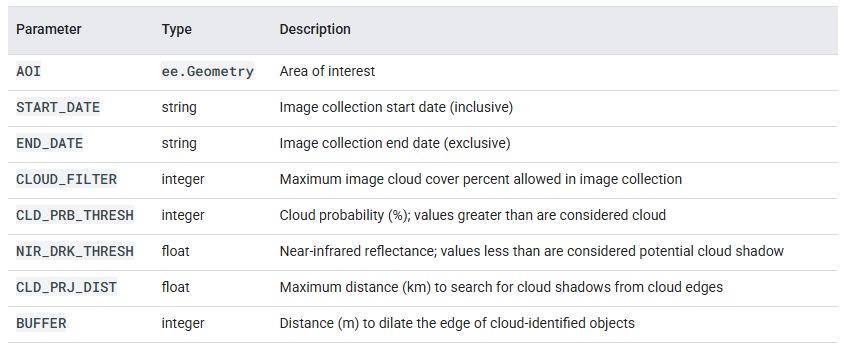

In [2]:
# Control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

Next we use these variables to build a Sentinel 2 image collection. You have done all this before, but now we are using more of the tools at our disposal to get exactly what we want.

Also, from now on we are going to be using functions to make our code more useable and extensible:

In [3]:
def get_s2_sr_cld_col(aoi, start_date, end_date):
    # Import and filter S2 SR.
    s2_sr_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte('CLOUDY_PIXEL_PERCENTAGE', CLOUD_FILTER)))

    # Import and filter s2cloudless.
    s2_cloudless_col = (ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY')
        .filterBounds(aoi)
        .filterDate(start_date, end_date))

    # Join the filtered s2cloudless collection to the SR collection by the 'system:index' property.
    return ee.ImageCollection(ee.Join.saveFirst('s2cloudless').apply(**{
        'primary': s2_sr_col,
        'secondary': s2_cloudless_col,
        'condition': ee.Filter.equals(**{
            'leftField': 'system:index',
            'rightField': 'system:index'
        })
    }))

In [4]:
# Apply the function in order to generate the collection
s2_sr_cld_col_eval = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [5]:
# As ever, a good idea to do a quick viusalization check
Map = geemap.Map()
Map.centerObject(AOI, 10)
Map.addLayer(s2_sr_cld_col_eval, {'bands':['B4','B3','B2'], 'min':0, 'max':3000}, 'S2 collection (before)')
Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Yup that is pretty cloudy!

Now, we will define a function to add the s2cloudless probability layer and derived cloud mask as bands to an S2 SR image input.

In [6]:
def add_cloud_bands(img):
    # Get s2cloudless image, subset the probability band.
    cld_prb = ee.Image(img.get('s2cloudless')).select('probability')

    # Condition s2cloudless by the probability threshold value.
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename('clouds')

    # Add the cloud probability layer and cloud mask as image bands.
    return img.addBands(ee.Image([cld_prb, is_cloud]))

The next function we need adds bands that add dark pixels, cloud projection, and identified shadows as bands to an S2 SR image input. Note that the image input needs to be the result of the above add_cloud_bands function because it relies on knowing which pixels are considered cloudy (via the renamed 'CLD_PRB_THRESH' band native to this S2 product).

In [7]:
def add_shadow_bands(img):
    # Identify water pixels from the SCL band.
    not_water = img.select('SCL').neq(6)

    # Identify dark NIR pixels that are not water (potential cloud shadow pixels).
    SR_BAND_SCALE = 1e4
    dark_pixels = img.select('B8').lt(NIR_DRK_THRESH*SR_BAND_SCALE).multiply(not_water).rename('dark_pixels')

    # Determine the direction to project cloud shadow from clouds (assumes UTM projection).
    shadow_azimuth = ee.Number(90).subtract(ee.Number(img.get('MEAN_SOLAR_AZIMUTH_ANGLE')));

    # Project shadows from clouds for the distance specified by the CLD_PRJ_DIST input.
    cld_proj = (img.select('clouds').directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST*10)
        .reproject(**{'crs': img.select(0).projection(), 'scale': 100})
        .select('distance')
        .mask()
        .rename('cloud_transform'))

    # Identify the intersection of dark pixels with cloud shadow projection.
    shadows = cld_proj.multiply(dark_pixels).rename('shadows')

    # Add dark pixels, cloud projection, and identified shadows as image bands.
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))

Finally for this stage, we define a function to assemble all of the cloud and cloud shadow components and produce the final mask.

In [8]:
def add_cld_shdw_mask(img):
    # Add cloud component bands.
    img_cloud = add_cloud_bands(img)

    # Add cloud shadow component bands.
    img_cloud_shadow = add_shadow_bands(img_cloud)

    # Combine cloud and shadow mask, set cloud and shadow as value 1, else 0.
    is_cld_shdw = img_cloud_shadow.select('clouds').add(img_cloud_shadow.select('shadows')).gt(0)

    # Remove small cloud-shadow patches and dilate remaining pixels by BUFFER input.
    # 20 m scale is for speed, and assumes clouds don't require 10 m precision.
    is_cld_shdw = (is_cld_shdw.focalMin(2).focalMax(BUFFER*2/20)
        .reproject(**{'crs': img.select([0]).projection(), 'scale': 20})
        .rename('cloudmask'))

    # Add the final cloud-shadow mask to the image.
    return img_cloud_shadow.addBands(is_cld_shdw)

Let us check this out and see how well it is dealing with our famously cloudy country. To do this we will need a function to pull out the cloud masking component layers, as in the 'final' version we will just apply this layer to remove the clouds rather than hold it as something we will display.

In [9]:
def display_cloud_layers_geemap(col, AOI):
    # Mosaic the image collection.
    img = col.mosaic()

    # Subset layers and prepare them for display.
    clouds = img.select('clouds').selfMask()
    shadows = img.select('shadows').selfMask()
    dark_pixels = img.select('dark_pixels').selfMask()
    probability = img.select('probability')
    cloudmask = img.select('cloudmask').selfMask()
    cloud_transform = img.select('cloud_transform')

    # Create a geemap Map object centered on AOI.
    m = geemap.Map()
    m.centerObject(AOI, 12)

    # Add layers
    m.addLayer(img, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1}, 'S2 image')
    m.addLayer(probability, {'min': 0, 'max': 100}, 'probability (cloud)')
    m.addLayer(clouds, {'palette': ['e056fd']}, 'clouds')
    m.addLayer(cloud_transform, {'min': 0, 'max': 1, 'palette': ['white', 'black']}, 'cloud_transform')
    m.addLayer(dark_pixels, {'palette': ['orange']}, 'dark_pixels')
    m.addLayer(shadows, {'palette': ['yellow']}, 'shadows')
    m.addLayer(cloudmask, {'palette': ['orange']}, 'cloudmask')

    return m

In [10]:
s2_sr_cld_col_eval_disp = s2_sr_cld_col_eval.map(add_cld_shdw_mask)
display_map = display_cloud_layers_geemap(s2_sr_cld_col_eval_disp, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Well now! That is considerably better than what we have been using before!

# Question 01:
Zoom in to a cloudy region and look at the S2 image, 'clouds' layer, 'dark pixels',  and the 'shadows' layers. Write a short paragraph that discusses:
- The performance of each masking element. Are they perfect or getting confused? What is causing the confusion?
- How do the three elements work together to define pixels that are not clear?
I am looking for you to show an understanding of both the algorithim you have just applied and the underlying spectral sensing principles.

(10 pts)

*   The three masking components (cloud probability, dark pixels, and projected shadows) each capture distinct physical characteristics of clouds, but none is perfect on its own. The cloud probability layer (s2cloudless) performs well at detecting bright, highly reflective clouds due to their high reflectance in visible bands, particularly the blue band, but can be confused with other bright surfaces such as rooftops or sand. The dark pixel mask (NIR threshold) identifies potential shadow regions because cloud shadows reduce reflectance in the near-infrared, but it can also incorrectly classify naturally dark surfaces such as water or dense vegetation. The shadow projection layer attempts to spatially link clouds to their shadow regions based on solar geometry, but errors in cloud height assumptions or terrain effects can lead to misalignment. Together, these components complement each other: cloud probability identifies likely clouds, dark pixels identify potential shadow areas, and shadow projection connects the two spatially. By combining spectral reflectance properties with geometric relationships, the algorithm more reliably identifies non-clear pixels than any single component alone.

# Question 02:
Exercise: change the above CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, and BUFFER input variables and rerun the previous cells to see how the results change. Present a figure that compares between the first version you ran and your final version. State the values you have selected and describe the improvements in performance you have managed to achieve in the figure caption.

(10 pts)

In [11]:
# Defining Parameter Sets for Comparison:
param_sets = {
    "baseline": {
        "CLD_PRB_THRESH": 50,
        "NIR_DRK_THRESH": 0.15,
        "CLD_PRJ_DIST": 1,
        "BUFFER": 50
    },

    "more_strict_cloud_removal": {
        "CLD_PRB_THRESH": 60,
        "NIR_DRK_THRESH": 0.20,
        "CLD_PRJ_DIST": 2,
        "BUFFER": 100
    },

    "less_strict_cloud_removal": {
        "CLD_PRB_THRESH": 40,
        "NIR_DRK_THRESH": 0.10,
        "CLD_PRJ_DIST": 1,
        "BUFFER": 30
    }
}

In [12]:
# Function Setup to Apply Parameters Safely:
def run_cloud_pipeline(params):

    global CLD_PRB_THRESH, NIR_DRK_THRESH, CLD_PRJ_DIST, BUFFER

    CLD_PRB_THRESH = params["CLD_PRB_THRESH"]
    NIR_DRK_THRESH = params["NIR_DRK_THRESH"]
    CLD_PRJ_DIST = params["CLD_PRJ_DIST"]
    BUFFER = params["BUFFER"]

    # rebuild collection
    col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

    # apply full cloud mask pipeline
    def mask(img):
        img = add_cld_shdw_mask(img)
        return img.updateMask(img.select('clouds').Not())

    clean_col = col.map(mask)

    return clean_col.mosaic()

In [13]:
# Generating outputs for each case:
results = {}

for name, params in param_sets.items():
    results[name] = run_cloud_pipeline(params)

In [14]:
# Visualise Map:
Map = geemap.Map()
Map.centerObject(AOI, 10)

vis = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}

for name, img in results.items():
    Map.addLayer(img, vis, name)

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

*   The original cloud-masking configuration used a cloud probability threshold (CLD_PRB_THRESH) of 50%, a near-infrared dark-pixel threshold (NIR_DRK_THRESH) of 0.15, a cloud-shadow projection distance (CLD_PRJ_DIST) of 1 km, and a cloud-edge buffer (BUFFER) of 50 m. Two alternative configurations were tested to examine the sensitivity of the masking procedure. The final selected configuration used CLD_PRB_THRESH = 60, NIR_DRK_THRESH = 0.20, CLD_PRJ_DIST = 2 km, and BUFFER = 100 m.
*   Compared with the baseline, increasing the cloud-probability threshold required pixels to have stronger evidence from s2cloudless before being identified as cloud, helping to reduce the classification of spectrally bright but cloud-free surfaces. Increasing the NIR dark-pixel threshold allowed a wider range of low-NIR pixels to be considered potential cloud shadows, while increasing the projection distance from 1 km to 2 km allowed shadows located further from their associated clouds to be detected. The increase in buffer from 50 m to 100 m also expanded the masked region around detected clouds, improving the removal of partially cloudy and transitional pixels at cloud edges. Overall, the final parameter combination produced a more spatially complete cloud-and-shadow mask than the baseline while retaining the higher cloud-probability requirement to limit unnecessary masking of clear surfaces.
*   Figure 01. Comparison of Sentinel-2 cloud-clearing results produced using different S2Cloudless masking parameters over the Auckland study area. The baseline configuration used CLD_PRB_THRESH = 50, NIR_DRK_THRESH = 0.15, CLD_PRJ_DIST = 1 km, and BUFFER = 50 m. The final configuration used CLD_PRB_THRESH = 60, NIR_DRK_THRESH = 0.20, CLD_PRJ_DIST = 2 km, and BUFFER = 100 m. The final configuration applies a more conservative initial cloud-probability threshold while increasing the extent of potential shadow detection and cloud-edge buffering, producing more complete masking around cloud and shadow boundaries.


Finally for this section, let's apply this cloud mask to our data and generate a 'cloud free' image. Replace my parameters used below with the ones you have selected based on your answer to question 2.

In [17]:
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

In [18]:
# Define a function to apply the cloud mask to the S2 spectral bands
def apply_cld_shdw_mask(img):
    cloudmask = img.select('cloudmask')
    # Mask cloudy pixels
    masked_img = img.updateMask(cloudmask.Not())
    # Keep cloudmask and probability bands
    cloudmask_band = img.select('cloudmask')
    probability_band = img.select('probability')
    masked_img = masked_img.addBands([cloudmask_band, probability_band], overwrite=True)
    return masked_img

In [20]:
# Process the collection
s2_sr_median = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .median())

In [21]:
# Display the cloud free composite
def display_cloud_free_mosaic(s2_sr_median, AOI):
    # Create a geemap Map object and center it on the AOI
    m = geemap.Map()
    m.centerObject(AOI, 12)

    # Add the Sentinel-2 RGB mosaic
    m.addLayer(
        s2_sr_median,
        {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500, 'gamma': 1.1},
        'S2 cloud-free mosaic')

    return m

display_map = display_cloud_free_mosaic(s2_sr_median, AOI)
display_map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Now THAT is a cloud-free image! (Well, with my thresholds we still have a little there over the SW forest, can yours do better?).


________________________________________________________________________________

# Question 03:
This process has managed to avoid masking out the many bright white roofs of Auckland as cloud, despite them appearing very similar to cloud in the RGB visualization. How has the algorithm achieved this?
(5 pts)

*   The algorithm avoids misclassifying bright roofs as clouds by incorporating multi-spectral information beyond RGB, particularly the shortwave infrared (SWIR) and near-infrared (NIR) bands. While both clouds and rooftops appear bright in visible wavelengths, clouds exhibit low reflectance in SWIR and distinct spectral signatures compared to man-made materials. The s2cloudless model uses these spectral differences, along with learned patterns from training data, to distinguish true clouds from spectrally dissimilar bright surfaces. Additionally, the inclusion of shadow detection and spatial context further reduces false positives, since rooftops do not produce the same shadow relationships as clouds.

# Extending S2 Cloudless with a clustering approach
The process we explored in the prior section has worked really rather well! But you saw in the exercise that it does rely on you setting the local paramaters. This is a manual process and one that is at risk of reduced effectiveness if we are clearing cloud over a wide area. This is particularly the case for cirrus and other thin clouds (e.g. cloud edges) that the thresholds are very sensitive to.

Therefore, let us extend our cloud-clearing algorithim into one that includes a clustering-step in which we sample the pixels around the edge of our clouds and test if they should be clustered into our cloud mask.

We will now implement the following workflow:
1.   Reset our data stack, with somewhat worse settings than the very good ones we have just set, in order to make this a better (for humans) teaching exercise.
2.   Define what counts as inside a cloud, outside a cloud and the edge of a cloud.
3.   Vizualize these samples and determine if we can perform meaningful clustering on them.
4.   Perform clustering of the border zone pixels with either the clouds or the cloud free.





In [22]:
# First, lets make our cloud clearing 'worse' in order to more clearly demonstrate our clustering alg
# Tweaked control variables
AOI = ee.Geometry.Point(174.7633, -36.8485)
START_DATE = '2023-01-01'
END_DATE = '2023-03-31'
CLOUD_FILTER = 30
CLD_PRB_THRESH = 30
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 5

# Re-collect the S2 as we have changed our filtering params
s2_sr_cld_col = get_s2_sr_cld_col(AOI, START_DATE, END_DATE)

# Re-run s2cloudless approach, this time with .moasic as the compositing operator
s2_sr_mosaic = (s2_sr_cld_col.map(add_cld_shdw_mask)
                             .map(apply_cld_shdw_mask)
                             .mosaic()) #<- switched to mosaic to better preserve the cloud masking layers we want to now use for our k-means workflow

In [23]:
def define_cloud_zones(img, edge_buffer=120):
    cloudmask = img.select('cloudmask')

    # Interior cloud pixels: cloudmask==1, away from edges (small erosion)
    cloud_interior = cloudmask.selfMask().focal_min(3)

    # Interior clear pixels: cloudmask==0, away from edges (medium erosion)
    clear_interior = cloudmask.Not().selfMask().focal_min(10)

    # Cloud edge pixels: buffer zone around clouds, but outside cloudmask
    cloud_edge = cloudmask.focal_max(edge_buffer / 10).And(cloudmask.Not())

    return cloud_interior, clear_interior, cloud_edge


In [24]:
def sample_zones(img, AOI, edge_buffer=20):
    cloudmask = img.select('cloudmask')

    cloud_interior = cloudmask.selfMask()
    clear_interior = cloudmask.Not().selfMask()
    cloud_edge = cloudmask.focal_max(edge_buffer).And(cloudmask.Not())

    sample_bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B9', 'B8', 'B11', 'B12']
    if 'probability' in img.bandNames().getInfo():
        sample_bands.append('probability')

    img_for_sampling = img.select(sample_bands)

    cloud_samples = img_for_sampling.updateMask(cloud_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=0, geometries=True)

    clear_samples = img_for_sampling.updateMask(clear_interior).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=1, geometries=True)

    edge_samples = img_for_sampling.updateMask(cloud_edge).sample(
        region=AOI.buffer(2000), scale=10, numPixels=5000, seed=2, geometries=True)

    return cloud_samples, clear_samples, edge_samples


In [25]:
# Gather our samples
cloud_samples, clear_samples, edge_samples = sample_zones(s2_sr_mosaic, AOI)

# Function to convert a earth engine feature class to a pandas df
def fc_to_df(fc):
    features = fc.getInfo()['features']
    rows = []
    for f in features:
        props = f['properties']
        coords = f['geometry']['coordinates']
        props['longitude'] = coords[0]
        props['latitude'] = coords[1]
        rows.append(props)
    return pd.DataFrame(rows)


# Carry out the conversion and sanity print out what we have
cloud_df = fc_to_df(cloud_samples)
clear_df = fc_to_df(clear_samples)
edge_df = fc_to_df(edge_samples)

print(f"Cloud samples: {len(cloud_df)}")
print(f"Clear samples: {len(clear_df)}")
print(f"Edge samples: {len(edge_df)}")
print("Cloud columns:", cloud_df.columns)


Cloud samples: 727
Clear samples: 4310
Edge samples: 1930
Cloud columns: Index(['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B9', 'probability',
       'longitude', 'latitude'],
      dtype='object')


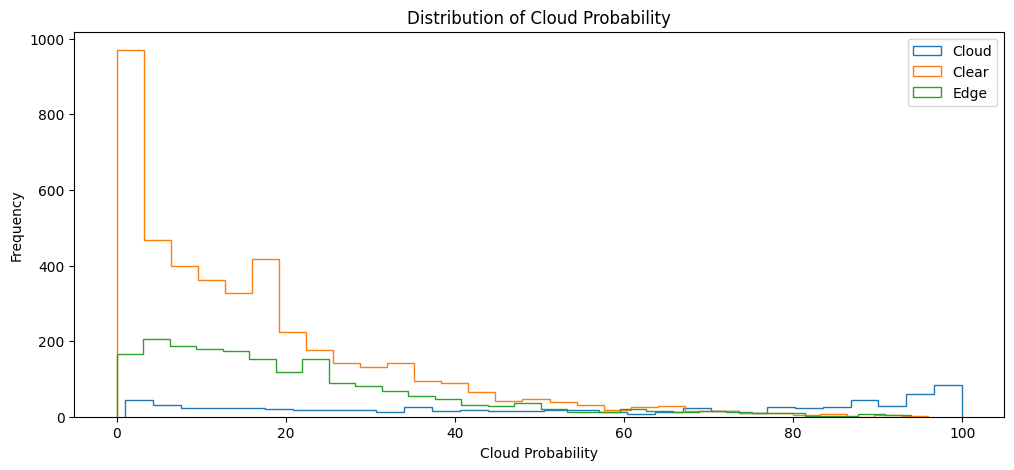

In [26]:
# Histogram of cloud probability by class
plt.figure(figsize=(12, 5))
plt.hist(cloud_df['probability'], bins=30, histtype='step', label='Cloud')
plt.hist(clear_df['probability'], bins=30, histtype='step', label='Clear')
plt.hist(edge_df['probability'], bins=30, histtype='step', label='Edge')
plt.xlabel('Cloud Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Cloud Probability')
plt.show()

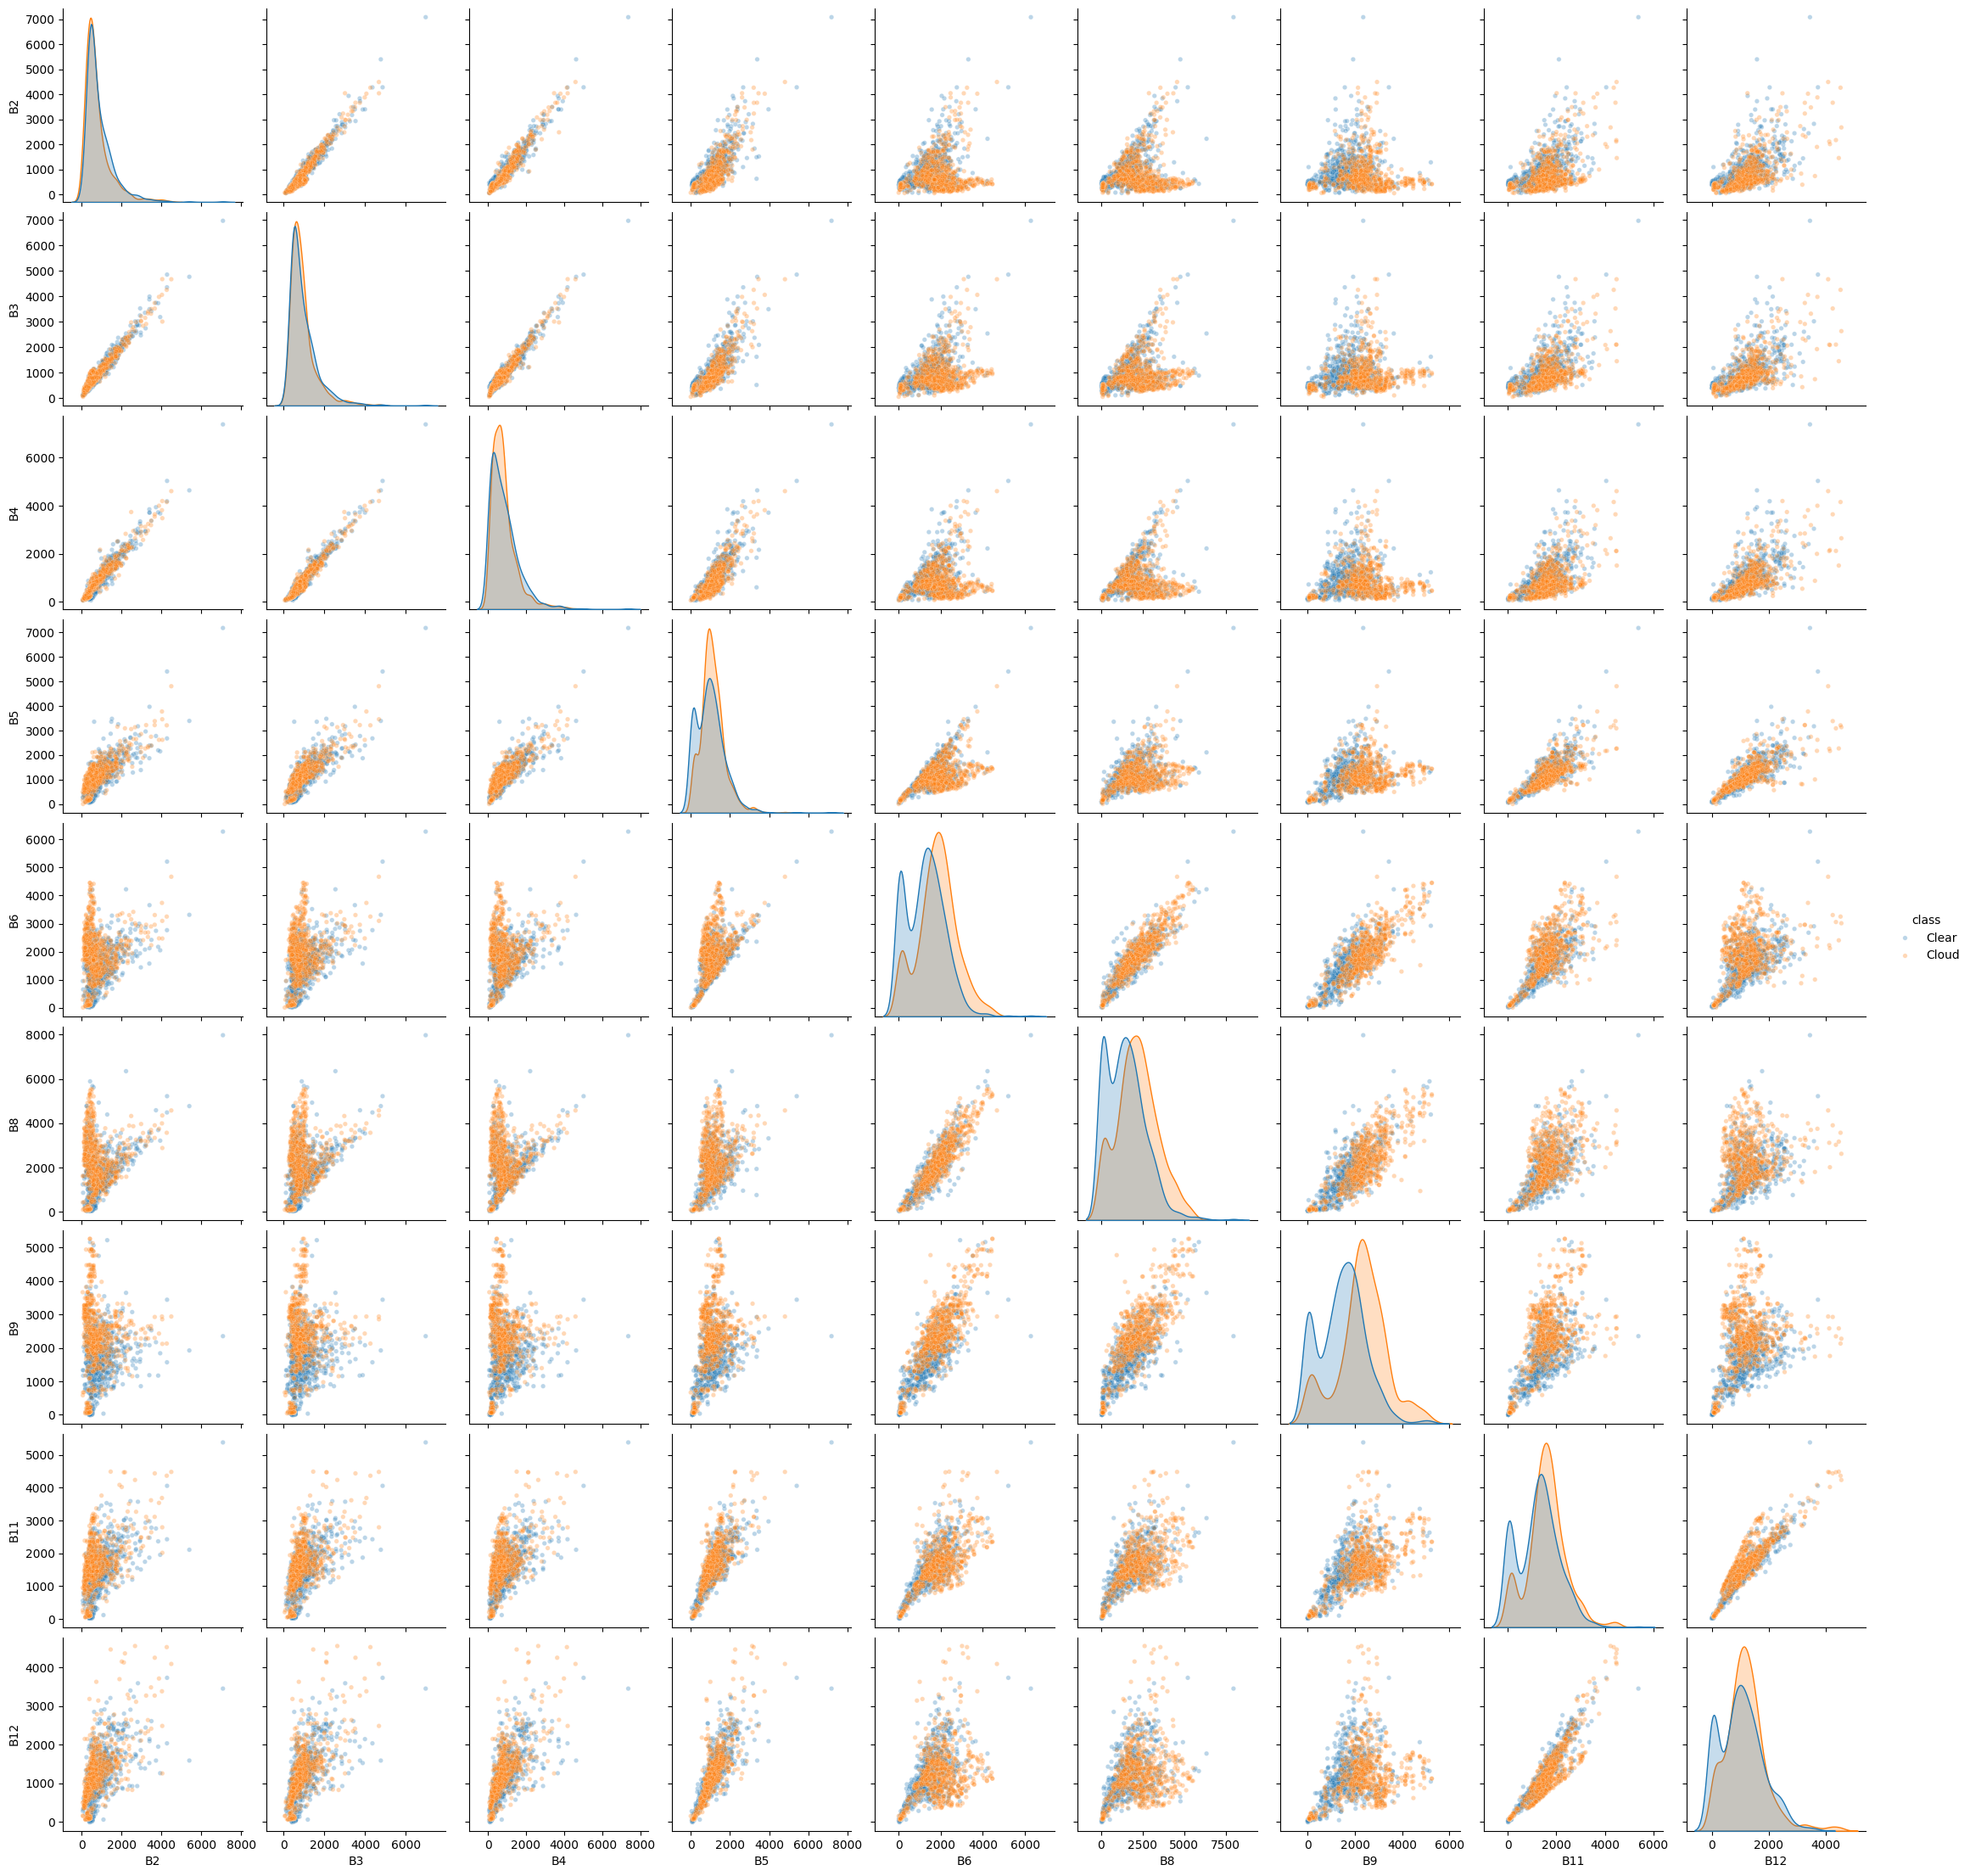

In [27]:
# Plot out all the bands, by the two 'labelled' classes that we want to discriminate between
# Add class labels
cloud_df['class'] = 'Cloud'
clear_df['class'] = 'Clear'

# Combine to one df
combined_df = pd.concat([cloud_df, clear_df])

# We will carry out somne class balancing here
# Find smallest class count
min_count = combined_df['class'].value_counts().min()

# Downsample each class to min_count
balanced_df = combined_df.groupby('class').sample(n=min_count, random_state=42)

# Now plot with balanced_df
# This is going to make a big plot that you will have to scroll around! Pay particular attention to the histogram plots on the diagonal.
bands = ['B2', 'B3', 'B4', 'B5', 'B6' , 'B8', 'B9', 'B11', 'B12']
sns.pairplot(balanced_df, vars=bands, hue='class', plot_kws={'alpha':0.3, 's':15}, height=2.5)


# Question 04:
What do the histograms of cloud detection probability (as judged by s2cloudless) plotted in the three classes we have set here, AND the pair plot of all bands available tell us about our ability to tell cloudy vs non-cloud pixels apart? Make sure to explain your answer with reference to physical principles and the statistical foundations of ML (5 pts)

*   The histograms of cloud detection probability show that cloudy pixels tend to cluster at high probability values, while clear pixels cluster at low values, indicating that the model can generally separate the two classes. However, overlap between distributions suggests ambiguity in transitional or mixed pixels (e.g., cloud edges). The pair plot of spectral bands reveals that certain band combinations provide better separation between cloudy and non-cloudy pixels, particularly those involving visible vs SWIR/NIR reflectance differences. Clear clustering in feature space indicates that spectral information is useful for classification, but overlapping regions highlight the need for more advanced methods (e.g., clustering or contextual analysis) to handle edge cases.

# Question 05:
Which bands are therefore going to be the best to use in our K-means clustering approach and why? (5 pts)

*   The most effective bands for K-means clustering are those that maximise the separation between cloud and non-cloud pixels, particularly the blue, NIR, and SWIR bands. Clouds are highly reflective in the blue band but relatively dark in SWIR, while vegetation is bright in NIR and darker in visible wavelengths. Using combinations of these bands enhances contrast between classes in feature space, allowing clustering algorithms to better distinguish clouds, clear land, and transitional pixels. Including bands with complementary spectral responses improves cluster separability and overall classification performance.

With our choices made, let us now test if we can implement k-means as a tool by which to assign those edge pixels into either the cloudy or clear classes. Noting that I have placed default band choices in the 'features to use for clustering' line. You do not need to use just three bands.

Run this section first with the default bands, and then change it to the ones you have selected in question 5. Observe the difference it makes...

In [28]:
# Use the balanced_df from before for cloud and clear pixels only
train_df = balanced_df[balanced_df['class'].isin(['Cloud', 'Clear'])]

# Features to use for clustering
features = ['B2', 'B3', 'B4']

# Prepare training data (cloud=1, clear=0)
X_train = train_df[features].values
y_train = (train_df['class'] == 'Cloud').astype(int).values

# Fit k-means with 2 clusters on training data
kmeans = KMeans(n_clusters=2, random_state=42).fit(X_train)

# Map clusters to classes by majority vote on training data
labels, counts = np.unique(kmeans.labels_[y_train==0], return_counts=True)
clear_cluster = labels[np.argmax(counts)]
labels, counts = np.unique(kmeans.labels_[y_train==1], return_counts=True)
cloud_cluster = labels[np.argmax(counts)]

# Prepare edge pixels data for prediction
edge_features = edge_df[features].values

# Predict clusters for edge pixels
edge_clusters = kmeans.predict(edge_features)

# Assign class labels to edge pixels based on cluster
edge_df['predicted_class'] = ['Cloud' if c == cloud_cluster else 'Clear' for c in edge_clusters]

# Quick summary
print(edge_df['predicted_class'].value_counts())


predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


And now plot up the results of this below. Play around with this plotting and take a look at each set of band combinations you have chosen. Think about where the boundary is being placed, does it make sense?

predicted_class
Cloud    1512
Clear     418
Name: count, dtype: int64


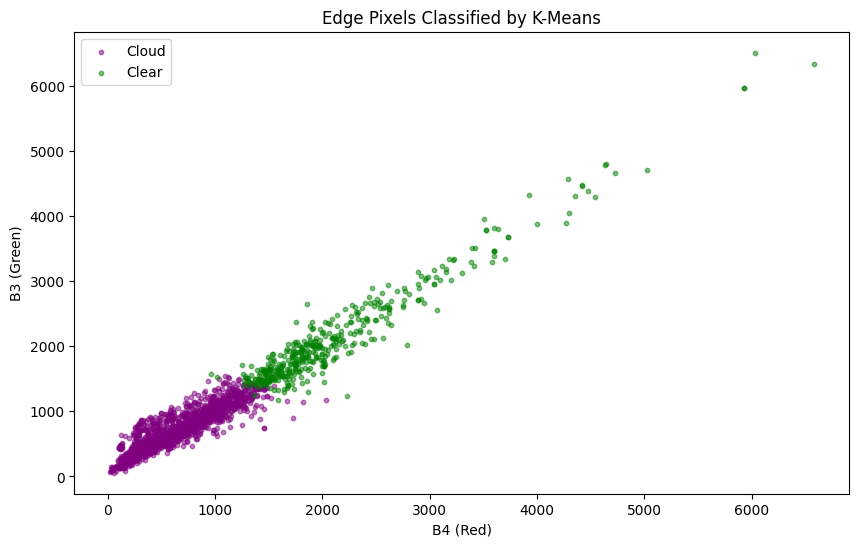

In [29]:
# Count of predicted classes
counts = edge_df['predicted_class'].value_counts()
print(counts)

# Scatter plot of edge pixels B4 vs B3 colored by predicted class ### CHANGE THIS TO YOUR OTHER BANDS ###
plt.figure(figsize=(10, 6))
for label, color in zip(['Cloud', 'Clear'], ['purple', 'green']):
    subset = edge_df[edge_df['predicted_class'] == label]
    plt.scatter(subset['B4'], subset['B3'], label=label, alpha=0.5, s=10, c=color)

plt.xlabel('B4 (Red)')
plt.ylabel('B3 (Green)')
plt.title('Edge Pixels Classified by K-Means')
plt.legend()
plt.show()


Finally, we will map this back onto earth engine via the following workflow:
1.  Export the classified edge pixels back to Earth Engine as a FeatureCollection
2. Rasterize the classified edge points into an image layer
3. Visualize refined cloud mask in Earth Engine (geemap):

Export to Earth Engine FC:

In [30]:
# Function to go the other way! This time from a dataframe to the feature collection
def df_to_ee_fc(df):
    features = []
    for _, row in df.iterrows():
        geom = ee.Geometry.Point([row['longitude'], row['latitude']])
        props = {k: float(row[k]) for k in ['B2', 'B3', 'B4', 'B8', 'probability']}
        props['predicted_class'] = row['predicted_class']
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

edge_fc = df_to_ee_fc(edge_df)

Rasterize into image layer:

In [31]:
# Map predicted class to numeric
def class_to_numeric(feature):
    cls = feature.get('predicted_class')
    return feature.set('cloud_refined', ee.Number(ee.Algorithms.If(ee.String(cls).equals('Cloud'), 1, 0)))

edge_fc_num = edge_fc.map(class_to_numeric)

# Rasterize: paint 'cloud_refined' on a blank image
refined_cloud_mask = edge_fc_num.reduceToImage(
    properties=['cloud_refined'],
    reducer=ee.Reducer.first())

# Optionally, you can combine this refined mask with your existing cloudmask for a final refined mask
final_mask = s2_sr_median.select('cloudmask').max(refined_cloud_mask).rename('cloudmask_refined')


Visualize it:

In [32]:
Map = geemap.Map()
Map.centerObject(AOI, 12)

# Show original cloudmask
Map.addLayer(s2_sr_median.select('cloudmask'), {'palette': ['white', 'red']}, 'Original cloudmask')

# Show refined cloudmask
Map.addLayer(final_mask.selfMask(), {'palette': ['blue']}, 'Refined cloudmask')

Map

Map(center=[-36.84850000000001, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], pos…

Hopefully, what you should now see above is a patch of downtown Auckland that has your s2cloudless cloudmask and a scatter of blue pixels (i.e. the sample from within the AOI) that k-means has decided is cloud.

Your answer to Q5 should see this scatter of 'new cloudy' pixels be better associated with the known clouds than if you leave it as the default bands that I have provided.





# Question 06:
Exercise: take all you have learned in this lab and carry out the following improvements:
1. Increase the K-means sampling to be more representative of the whole scene. This means; sample regions for cloud, clear and cloud edge that are not just over downtown Auckland but from across multiple landcover types.
2. Take the model that you have trained here using SciKitLearn and use it to classify edge pixels across a whole satellite image.

Present your results in **two** figures. The first should show the results of upgrades to pt.1, the second the results of pt.2.

(15 pts)

To get you started on item 2, this might be how you plan out your workflow given that you cannot upload a python ML model directly to Earth Engine:
- Extract cluster centres from Python k-means.
- Pass centres as constants into EE.
- Write a per-pixel classification function assigning nearest cluster centre.
- Apply this function to edge pixels or the whole image as needed.

In [33]:
# ============================================================
# Q6.1: Prepare an unmasked image for K-means sampling
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

# IMPORTANT:
# Do not apply apply_cld_shdw_mask() here because we need the
# original spectral values of cloudy pixels for K-means.

s2_analysis_mosaic = (
    s2_sr_cld_col
    .map(add_cld_shdw_mask)
    .mosaic()
)

# Use the footprint of the first Sentinel-2 image as the
# full-scene processing region.
FULL_SCENE = ee.Image(s2_sr_cld_col.first()).geometry()

# Use the bands selected from your Q5 analysis.
# Change this list if your Q5 answer selected different bands.
FEATURES = ['B2', 'B8', 'B11', 'B12']

# At 20 m, all selected bands are sampled at a common resolution.
SAMPLE_SCALE = 20

# Width of the zone outside the original cloud mask.
EDGE_WIDTH_M = 200

print("Bands used for K-means:", FEATURES)
print("Full Sentinel-2 scene prepared.")

Bands used for K-means: ['B2', 'B8', 'B11', 'B12']
Full Sentinel-2 scene prepared.


In [34]:
# ============================================================
# Define training and classification zones
# ============================================================

cloudmask_q6 = (
    s2_analysis_mosaic
    .select('cloudmask')
    .unmask(0)
    .gt(0)
)

# Pixels well inside known clouds.
cloud_interior_q6 = (
    cloudmask_q6
    .focal_min(radius=60, units='meters')
    .eq(1)
)

# Pixels well inside known clear areas.
clear_interior_q6 = (
    cloudmask_q6
    .Not()
    .focal_min(radius=100, units='meters')
    .eq(1)
)

# Pixels immediately outside the existing cloud mask.
edge_zone_q6 = (
    cloudmask_q6
    .focal_max(radius=EDGE_WIDTH_M, units='meters')
    .And(cloudmask_q6.Not())
)

print("Cloud, clear and edge zones created.")

Cloud, clear and edge zones created.


In [35]:
# ============================================================
# Representative sampling across multiple land-cover types
# ============================================================

worldcover = (
    ee.ImageCollection('ESA/WorldCover/v200')
    .first()
    .select('Map')
    .rename('landcover')
)

# WorldCover classes likely to occur around Auckland.
LANDCOVER_CODES = [10, 20, 30, 40, 50, 60, 80, 90, 95]
POINTS_PER_LANDCOVER = 150

sampling_image = (
    s2_analysis_mosaic
    .select(FEATURES + ['probability'])
    .addBands(worldcover)
)

def stratified_zone_sample(zone_mask, seed):
    """
    Sample approximately the same number of pixels from each
    available land-cover class within a cloud/clear/edge zone.
    """
    return (
        sampling_image
        .updateMask(zone_mask)
        .stratifiedSample(
            numPoints=0,
            classBand='landcover',
            region=FULL_SCENE,
            scale=SAMPLE_SCALE,
            seed=seed,
            classValues=LANDCOVER_CODES,
            classPoints=[POINTS_PER_LANDCOVER] * len(LANDCOVER_CODES),
            dropNulls=True,
            tileScale=4,
            geometries=True
        )
    )

cloud_samples_q6 = stratified_zone_sample(cloud_interior_q6, seed=10)
clear_samples_q6 = stratified_zone_sample(clear_interior_q6, seed=20)
edge_samples_q6  = stratified_zone_sample(edge_zone_q6, seed=30)

print("Cloud samples:", cloud_samples_q6.size().getInfo())
print("Clear samples:", clear_samples_q6.size().getInfo())
print("Edge samples:", edge_samples_q6.size().getInfo())

Cloud samples: 1350
Clear samples: 1350
Edge samples: 1350


In [37]:
# ============================================================
# Convert Earth Engine samples to pandas dataframes
# ============================================================

LANDCOVER_NAMES = {
    10: 'Tree cover',
    20: 'Shrubland',
    30: 'Grassland',
    40: 'Cropland',
    50: 'Built-up',
    60: 'Bare/sparse',
    80: 'Permanent water',
    90: 'Wetland',
    95: 'Mangroves'
}

def fc_to_df_q6(feature_collection):
    rows = []

    for feature in feature_collection.getInfo()['features']:
        row = feature['properties'].copy()
        coordinates = feature['geometry']['coordinates']

        row['longitude'] = coordinates[0]
        row['latitude'] = coordinates[1]
        rows.append(row)

    output = pd.DataFrame(rows)

    if len(output) > 0:
        output['landcover_name'] = (
            output['landcover']
            .astype(int)
            .map(LANDCOVER_NAMES)
            .fillna('Other')
        )

    return output

cloud_df_q6 = fc_to_df_q6(cloud_samples_q6)
clear_df_q6 = fc_to_df_q6(clear_samples_q6)
edge_df_q6  = fc_to_df_q6(edge_samples_q6)

cloud_df_q6['zone'] = 'Cloud interior'
clear_df_q6['zone'] = 'Clear interior'
edge_df_q6['zone']  = 'Cloud edge'

all_samples_q6 = pd.concat(
    [cloud_df_q6, clear_df_q6, edge_df_q6],
    ignore_index=True
)

# Numerical evidence that the samples cover multiple land-cover types.
sample_summary = pd.crosstab(
    all_samples_q6['landcover_name'],
    all_samples_q6['zone']
)

display(sample_summary)

zone,Clear interior,Cloud edge,Cloud interior
landcover_name,,,
Bare/sparse,150,150,150
Built-up,150,150,150
Cropland,150,150,150
Grassland,150,150,150
Mangroves,150,150,150
Permanent water,150,150,150
Shrubland,150,150,150
Tree cover,150,150,150
Wetland,150,150,150


In [38]:
# ============================================================
# FIGURE 1: Full-scene representative sampling
# ============================================================

import ipywidgets as widgets
from ipyleaflet import WidgetControl

def add_north_arrow(map_object):
    north_widget = widgets.HTML(
        value="""
        <div style="
            background:white;
            border:1px solid black;
            padding:5px 9px;
            text-align:center;
            font-weight:bold;
            font-size:18px;
            line-height:18px;">
            N<br>↑
        </div>
        """
    )

    map_object.add_control(
        WidgetControl(widget=north_widget, position='topright')
    )

def add_attribution_box(map_object, text):
    attribution_widget = widgets.HTML(
        value=f"""
        <div style="
            background:rgba(255,255,255,0.88);
            padding:4px 7px;
            font-size:10px;
            max-width:420px;">
            {text}
        </div>
        """
    )

    map_object.add_control(
        WidgetControl(widget=attribution_widget, position='bottomright')
    )

Map1 = geemap.Map()
Map1.centerObject(FULL_SCENE, 8)

rgb_vis = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000,
    'gamma': 1.1
}

Map1.addLayer(
    s2_analysis_mosaic.clip(FULL_SCENE),
    rgb_vis,
    'Sentinel-2 RGB'
)

# Show a manageable number of points while preserving their spread.
Map1.addLayer(
    cloud_samples_q6.limit(1500).style(
        color='d73027',
        pointSize=3,
        width=1
    ),
    {},
    'Cloud-interior samples'
)

Map1.addLayer(
    clear_samples_q6.limit(1500).style(
        color='1a9850',
        pointSize=3,
        width=1
    ),
    {},
    'Clear-interior samples'
)

Map1.addLayer(
    edge_samples_q6.limit(1500).style(
        color='4575b4',
        pointSize=3,
        width=1
    ),
    {},
    'Cloud-edge samples'
)

Map1.add_legend(
    title='Sampling zone',
    legend_dict={
        'Cloud interior': '#d73027',
        'Clear interior': '#1a9850',
        'Cloud edge': '#4575b4'
    }
)

add_north_arrow(Map1)

add_attribution_box(
    Map1,
    "Data: Copernicus Sentinel-2 and s2cloudless; "
    "land-cover strata: ESA WorldCover 2021; "
    "processing: Google Earth Engine."
)

Map1

Map(center=[-36.6076493439497, 174.25943836980744], controls=(WidgetControl(options=['position', 'transparent_…

*   Figure 2. Representative full-scene sampling used to train and evaluate the K-means cloud-edge classifier. Cloud-interior, clear-interior, and cloud-edge samples were stratified across the land-cover classes present in the Sentinel-2 scene, rather than restricted to downtown Auckland. Red points represent cloud-interior samples, green points represent clear-interior samples, and blue points represent candidate cloud-edge pixels.

In [39]:
# ============================================================
# Train K-means using representative cloud and clear samples
# ============================================================

cloud_training = cloud_df_q6.copy()
clear_training = clear_df_q6.copy()

cloud_training['known_class'] = 'Cloud'
clear_training['known_class'] = 'Clear'

training_df_q6 = pd.concat(
    [cloud_training, clear_training],
    ignore_index=True
)

# Remove any incomplete rows.
training_df_q6 = training_df_q6.dropna(
    subset=FEATURES + ['known_class']
)

# Balance known cloud and clear samples.
smallest_class = (
    training_df_q6['known_class']
    .value_counts()
    .min()
)

balanced_training_q6 = (
    training_df_q6
    .groupby('known_class', group_keys=False)
    .sample(n=smallest_class, random_state=42)
)

X_train_q6 = balanced_training_q6[FEATURES].values
y_train_q6 = (
    balanced_training_q6['known_class'] == 'Cloud'
).astype(int).values

# Standardisation prevents high-variance bands from dominating
# the Euclidean distances used by K-means.
scaler_q6 = StandardScaler()
X_train_scaled_q6 = scaler_q6.fit_transform(X_train_q6)

kmeans_q6 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

training_clusters_q6 = kmeans_q6.fit_predict(
    X_train_scaled_q6
)

# Determine which numerical cluster represents cloud.
cluster_vote = pd.DataFrame({
    'cluster': training_clusters_q6,
    'is_cloud': y_train_q6
})

cloud_fraction = (
    cluster_vote
    .groupby('cluster')['is_cloud']
    .mean()
)

cloud_cluster_q6 = int(cloud_fraction.idxmax())
clear_cluster_q6 = int(cloud_fraction.idxmin())

training_prediction_q6 = (
    training_clusters_q6 == cloud_cluster_q6
).astype(int)

print("Cluster cloud fractions:")
display(cloud_fraction.rename('fraction_cloud'))

print("Cloud cluster:", cloud_cluster_q6)
print("Clear cluster:", clear_cluster_q6)
print(
    "Agreement with known training zones:",
    round(accuracy_score(y_train_q6, training_prediction_q6), 3)
)

print("Cluster centres in standardised feature space:")
display(pd.DataFrame(
    kmeans_q6.cluster_centers_,
    columns=FEATURES,
    index=['Cluster 0', 'Cluster 1']
))

Cluster cloud fractions:


,fraction_cloud
cluster,
0,0.342955
1,0.989329


Cloud cluster: 1
Clear cluster: 0
Agreement with known training zones: 0.738
Cluster centres in standardised feature space:


,B2,B8,B11,B12
Cluster 0,-0.490533,-0.441793,-0.475703,-0.478998
Cluster 1,1.528429,1.376563,1.482222,1.492486


In [40]:
# ============================================================
# Classify sampled edge pixels in Python
# ============================================================

valid_edge_df_q6 = (
    edge_df_q6
    .dropna(subset=FEATURES)
    .copy()
)

edge_scaled_q6 = scaler_q6.transform(
    valid_edge_df_q6[FEATURES].values
)

edge_clusters_q6 = kmeans_q6.predict(edge_scaled_q6)

valid_edge_df_q6['predicted_class'] = np.where(
    edge_clusters_q6 == cloud_cluster_q6,
    'Cloud',
    'Clear'
)

print("Sampled edge-pixel predictions:")
display(valid_edge_df_q6['predicted_class'].value_counts())

Sampled edge-pixel predictions:


,count
predicted_class,
Clear,1325
Cloud,25


In [41]:
# ============================================================
# Transfer scaler statistics and cluster centres into EE
# ============================================================

feature_mean_q6 = scaler_q6.mean_
feature_scale_q6 = scaler_q6.scale_
cluster_centres_q6 = kmeans_q6.cluster_centers_

# Reproduce the StandardScaler transformation per pixel in EE.
standardised_bands_q6 = []

for band, mean_value, scale_value in zip(
    FEATURES,
    feature_mean_q6,
    feature_scale_q6
):
    standardised_band = (
        s2_analysis_mosaic
        .select(band)
        .toFloat()
        .subtract(float(mean_value))
        .divide(float(scale_value))
        .rename(band)
    )

    standardised_bands_q6.append(standardised_band)

standardised_image_q6 = ee.Image.cat(
    standardised_bands_q6
).select(FEATURES)

# Calculate squared Euclidean distance from each pixel
# to each fitted cluster centre.
distance_images_q6 = []

for cluster_number, centre in enumerate(cluster_centres_q6):
    centre_image = (
        ee.Image.constant(centre.tolist())
        .rename(FEATURES)
        .toFloat()
    )

    squared_distance = (
        standardised_image_q6
        .subtract(centre_image)
        .pow(2)
        .reduce(ee.Reducer.sum())
        .rename(f'distance_{cluster_number}')
    )

    distance_images_q6.append(squared_distance)

distance_stack_q6 = ee.Image.cat(distance_images_q6)

# arrayArgmax is applied to negative distance, which is
# equivalent to selecting the minimum original distance.
cluster_image_q6 = (
    distance_stack_q6
    .multiply(-1)
    .toArray()
    .arrayArgmax()
    .arrayGet([0])
    .rename('kmeans_cluster')
)

# Convert numerical clusters to Clear=0 and Cloud=1.
full_edge_classification_q6 = (
    cluster_image_q6
    .eq(cloud_cluster_q6)
    .rename('edge_class')
    .updateMask(edge_zone_q6)
    .clip(FULL_SCENE)
)

# Pixels newly added to the cloud mask by K-means.
new_edge_cloud_q6 = (
    full_edge_classification_q6
    .eq(1)
    .selfMask()
    .rename('new_edge_cloud')
)

# Combine the original mask with the newly classified cloud edges.
refined_cloudmask_q6 = (
    cloudmask_q6
    .Or(new_edge_cloud_q6.unmask(0))
    .rename('refined_cloudmask')
    .clip(FULL_SCENE)
)

print("The scikit-learn model has been reproduced in Earth Engine.")

The scikit-learn model has been reproduced in Earth Engine.


In [42]:
# ============================================================
# FIGURE 2: Classify every edge pixel across the full scene
# ============================================================

Map2 = geemap.Map()
Map2.centerObject(FULL_SCENE, 8)

Map2.addLayer(
    s2_analysis_mosaic.clip(FULL_SCENE),
    rgb_vis,
    'Sentinel-2 RGB'
)

# Original cloud and cloud-shadow mask.
Map2.addLayer(
    cloudmask_q6.selfMask().clip(FULL_SCENE),
    {'palette': ['d73027']},
    'Original cloud/shadow mask',
    True,
    0.55
)

# Classifications across the entire edge zone:
# 0 = clear edge, 1 = cloudy edge.
Map2.addLayer(
    full_edge_classification_q6,
    {
        'min': 0,
        'max': 1,
        'palette': ['1a9850', '4575b4']
    },
    'Full-scene K-means edge classification',
    True,
    0.85
)

# Optional combined final mask; initially switched off.
Map2.addLayer(
    refined_cloudmask_q6.selfMask(),
    {'palette': ['fdae61']},
    'Final refined cloud mask',
    False,
    0.65
)

Map2.add_legend(
    title='Classification',
    legend_dict={
        'Original cloud/shadow': '#d73027',
        'Edge classified clear': '#1a9850',
        'Edge classified cloud': '#4575b4',
        'Combined refined mask': '#fdae61'
    }
)

add_north_arrow(Map2)

add_attribution_box(
    Map2,
    "Data: Copernicus Sentinel-2 and s2cloudless; "
    "processing and full-scene classification: Google Earth Engine."
)

Map2

Map(center=[-36.6076493439497, 174.25943836980744], controls=(WidgetControl(options=['position', 'transparent_…

*   Figure 3. Full-scene classification of pixels surrounding the original S2Cloudless cloud-and-shadow mask. The scikit-learn cluster centres and standardisation parameters were transferred into Google Earth Engine, where every pixel within 200 m of the original mask was assigned to its nearest cluster centre. Red represents the original cloud-and-shadow mask, green represents edge pixels classified as clear, and blue represents edge pixels classified as cloud. The optional orange layer shows the final refined mask, combining the original mask with the additional cloudy edge pixels.

In [43]:
# ============================================================
# Prepare Q6 Figure 1 and Figure 2 for export
# ============================================================

# RGB background
rgb_export_q6 = (
    s2_analysis_mosaic
    .clip(FULL_SCENE)
    .visualize(
        bands=['B4', 'B3', 'B2'],
        min=0,
        max=3000,
        gamma=1.1
    )
)

# ------------------------------------------------------------
# FIGURE 1: Representative sampling
# ------------------------------------------------------------

cloud_points_image = (
    cloud_samples_q6
    .limit(1500)
    .style(
        color='d73027',
        pointSize=4,
        width=1
    )
)

clear_points_image = (
    clear_samples_q6
    .limit(1500)
    .style(
        color='1a9850',
        pointSize=4,
        width=1
    )
)

edge_points_image = (
    edge_samples_q6
    .limit(1500)
    .style(
        color='4575b4',
        pointSize=4,
        width=1
    )
)

figure1_ee = (
    rgb_export_q6
    .blend(cloud_points_image)
    .blend(clear_points_image)
    .blend(edge_points_image)
    .clip(FULL_SCENE)
)

# ------------------------------------------------------------
# FIGURE 2: Full-scene edge classification
# ------------------------------------------------------------

original_cloud_image = (
    cloudmask_q6
    .selfMask()
    .visualize(
        palette=['d73027'],
        opacity=0.60
    )
)

edge_classification_image = (
    full_edge_classification_q6
    .visualize(
        min=0,
        max=1,
        palette=['1a9850', '4575b4'],
        opacity=0.85
    )
)

figure2_ee = (
    rgb_export_q6
    .blend(original_cloud_image)
    .blend(edge_classification_image)
    .clip(FULL_SCENE)
)

print("Both Earth Engine figures are ready for export.")

Both Earth Engine figures are ready for export.


In [45]:
# ============================================================
# Export both figures from Earth Engine as GeoTIFF files
# ============================================================

# A 100 m export scale is suitable for a full Sentinel-2 tile.
# Reduce to 50 m if you want more detail and the download succeeds.
EXPORT_SCALE = 100

geemap.ee_export_image(
    figure1_ee,
    filename='Q6_Figure1_representative_sampling.tif',
    region=FULL_SCENE,
    scale=EXPORT_SCALE,
    crs='EPSG:2193',
    file_per_band=False
)

geemap.ee_export_image(
    figure2_ee,
    filename='Q6_Figure2_full_scene_classification.tif',
    region=FULL_SCENE,
    scale=EXPORT_SCALE,
    crs='EPSG:2193',
    file_per_band=False
)

print("GeoTIFF exports completed.")

Generating URL ...
Please wait ...
Data downloaded to /content/Q6_Figure1_representative_sampling.tif
Generating URL ...
Please wait ...
Data downloaded to /content/Q6_Figure2_full_scene_classification.tif
GeoTIFF exports completed.


In [46]:
# ============================================================
# Functions for publication-quality cartographic figures
# ============================================================

import rasterio
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def add_north_arrow(ax, x=0.93, y=0.80):
    """Add a north arrow using axis-relative coordinates."""

    ax.annotate(
        'N',
        xy=(x, y + 0.12),
        xytext=(x, y),
        xycoords='axes fraction',
        textcoords='axes fraction',
        ha='center',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='black',
        arrowprops=dict(
            facecolor='black',
            edgecolor='black',
            width=2,
            headwidth=10,
            headlength=10
        ),
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.70,
            pad=2
        )
    )


def add_scale_bar(ax, length_km=10, x_fraction=0.06, y_fraction=0.07):
    """
    Add an accurate scale bar.

    The exported raster uses EPSG:2193, whose coordinate units
    are metres.
    """

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    map_width = xmax - xmin
    map_height = ymax - ymin

    x_start = xmin + x_fraction * map_width
    y_position = ymin + y_fraction * map_height
    length_m = length_km * 1000

    # White background to keep the scale visible.
    ax.plot(
        [x_start, x_start + length_m],
        [y_position, y_position],
        color='white',
        linewidth=7,
        solid_capstyle='butt',
        zorder=9
    )

    # Black scale bar.
    ax.plot(
        [x_start, x_start + length_m],
        [y_position, y_position],
        color='black',
        linewidth=3,
        solid_capstyle='butt',
        zorder=10
    )

    # End ticks.
    tick_height = map_height * 0.012

    for x_tick in [x_start, x_start + length_m]:
        ax.plot(
            [x_tick, x_tick],
            [y_position - tick_height, y_position + tick_height],
            color='black',
            linewidth=2,
            zorder=10
        )

    ax.text(
        x_start + length_m / 2,
        y_position + map_height * 0.025,
        f'{length_km} km',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        zorder=10,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.75,
            pad=1.5
        )
    )


def plot_geotiff(
    tif_path,
    output_path,
    title,
    legend_handles,
    attribution,
    scale_length_km=10
):
    """Plot an exported Earth Engine GeoTIFF and save it as a PNG."""

    with rasterio.open(tif_path) as src:
        raster = src.read([1, 2, 3])
        raster = np.moveaxis(raster, 0, -1)

        bounds = src.bounds
        extent = [
            bounds.left,
            bounds.right,
            bounds.bottom,
            bounds.top
        ]

        # Use the dataset mask to make pixels outside the
        # Sentinel-2 footprint white rather than black.
        valid_mask = src.dataset_mask() > 0
        raster[~valid_mask] = 255

    fig, ax = plt.subplots(figsize=(13, 10))

    ax.imshow(
        raster,
        extent=extent,
        origin='upper'
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold',
        pad=14
    )

    add_north_arrow(ax)
    add_scale_bar(ax, length_km=scale_length_km)

    ax.legend(
        handles=legend_handles,
        loc='lower right',
        title='Legend',
        fontsize=10,
        title_fontsize=11,
        frameon=True,
        facecolor='white',
        edgecolor='black',
        framealpha=0.90
    )

    # Preserve map extent before hiding axes.
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.axis('off')

    fig.text(
        0.5,
        0.025,
        attribution,
        ha='center',
        va='bottom',
        fontsize=9,
        wrap=True
    )

    plt.tight_layout(rect=[0, 0.055, 1, 0.96])

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

    print(f"Saved: {output_path}")

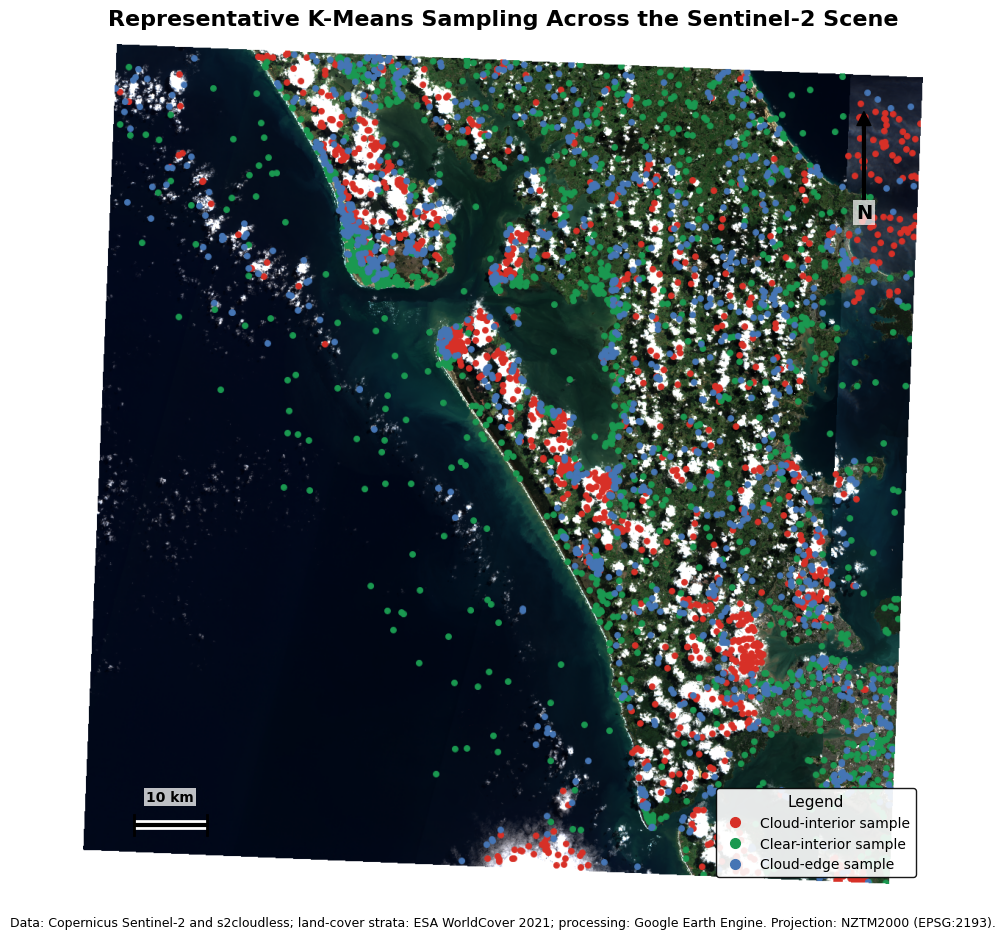

Saved: Q6_Figure1_representative_sampling.png


In [47]:
# ============================================================
# Q6 FIGURE 1: Representative sampling
# ============================================================

figure1_legend = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='#d73027',
        markeredgecolor='#d73027',
        markersize=7,
        label='Cloud-interior sample'
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='#1a9850',
        markeredgecolor='#1a9850',
        markersize=7,
        label='Clear-interior sample'
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor='#4575b4',
        markeredgecolor='#4575b4',
        markersize=7,
        label='Cloud-edge sample'
    )
]

plot_geotiff(
    tif_path='Q6_Figure1_representative_sampling.tif',
    output_path='Q6_Figure1_representative_sampling.png',
    title='Representative K-Means Sampling Across the Sentinel-2 Scene',
    legend_handles=figure1_legend,
    attribution=(
        'Data: Copernicus Sentinel-2 and s2cloudless; '
        'land-cover strata: ESA WorldCover 2021; '
        'processing: Google Earth Engine. '
        'Projection: NZTM2000 (EPSG:2193).'
    ),
    scale_length_km=10
)

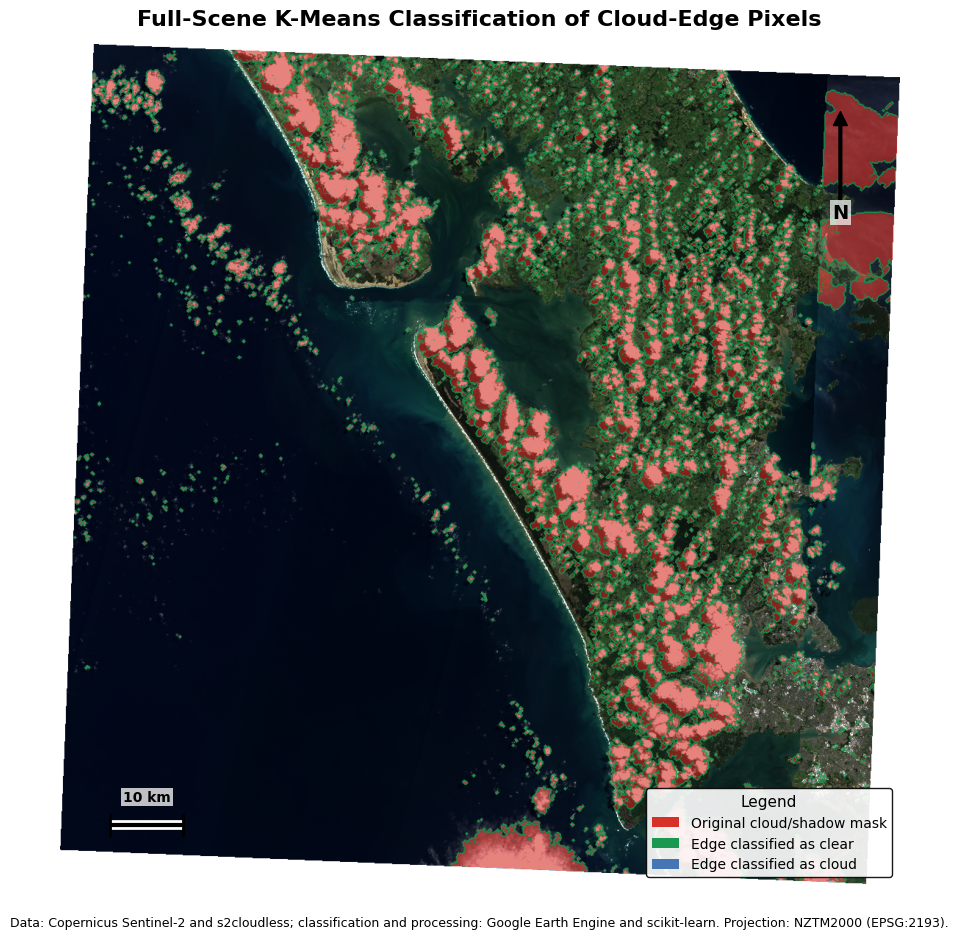

Saved: Q6_Figure2_full_scene_classification.png


In [48]:
# ============================================================
# Q6 FIGURE 2: Full-scene edge classification
# ============================================================

figure2_legend = [
    Patch(
        facecolor='#d73027',
        edgecolor='none',
        label='Original cloud/shadow mask'
    ),
    Patch(
        facecolor='#1a9850',
        edgecolor='none',
        label='Edge classified as clear'
    ),
    Patch(
        facecolor='#4575b4',
        edgecolor='none',
        label='Edge classified as cloud'
    )
]

plot_geotiff(
    tif_path='Q6_Figure2_full_scene_classification.tif',
    output_path='Q6_Figure2_full_scene_classification.png',
    title='Full-Scene K-Means Classification of Cloud-Edge Pixels',
    legend_handles=figure2_legend,
    attribution=(
        'Data: Copernicus Sentinel-2 and s2cloudless; '
        'classification and processing: Google Earth Engine '
        'and scikit-learn. Projection: NZTM2000 (EPSG:2193).'
    ),
    scale_length_km=10
)

In [49]:
from google.colab import files

files.download('Q6_Figure1_representative_sampling.png')
files.download('Q6_Figure2_full_scene_classification.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>